<a href="https://colab.research.google.com/github/ChrisCharlesArnold/Text-mining/blob/main/MSDA_683_Final_Project_Notebook_Chris_Arnold_Z106704.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries used in this lab
import numpy as np
import io
import nltk
import spacy
import pandas as pd
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import statsmodels.api as sm
import seaborn as sns

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to download the missing resource
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_workds = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#read in our spotify dataset
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/MSDA683/Module4ProjectData/songs.csv')

In [ ]:
# dataset size
df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [ ]:
print(df.keys())

Index(['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year',
       'genre', 'popularity', 'total_artist_followers',
       'avg_artist_popularity', 'artist_ids', 'niche_genres'],
      dtype='object')


In [ ]:
df.shape

(550622, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550622 entries, 0 to 550621
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      550622 non-null  object 
 1   name                    550619 non-null  object 
 2   album_name              550602 non-null  object 
 3   artists                 550622 non-null  object 
 4   danceability            550622 non-null  float64
 5   energy                  550622 non-null  float64
 6   key                     550622 non-null  int64  
 7   loudness                550622 non-null  float64
 8   mode                    550622 non-null  int64  
 9   speechiness             550622 non-null  float64
 10  acousticness            550622 non-null  float64
 11  instrumentalness        550622 non-null  float64
 12  liveness                550622 non-null  float64
 13  valence                 550622 non-null  float64
 14  tempo               

In [ ]:
#Setting up a Linear regression statistical test to test the significance
yearly = df.groupby("year")["valence"].mean().reset_index()

X_year = sm.add_constant(yearly["year"])
y_year = yearly["valence"]

model_year = sm.OLS(y_year, X_year).fit()

print(model_year.summary())

                            OLS Regression Results                            
Dep. Variable:                valence   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     22.02
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           8.32e-06
Time:                        23:36:09   Log-Likelihood:                 117.59
No. Observations:                 105   AIC:                            -231.2
Df Residuals:                     103   BIC:                            -225.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8740      0.498      5.767      0.0

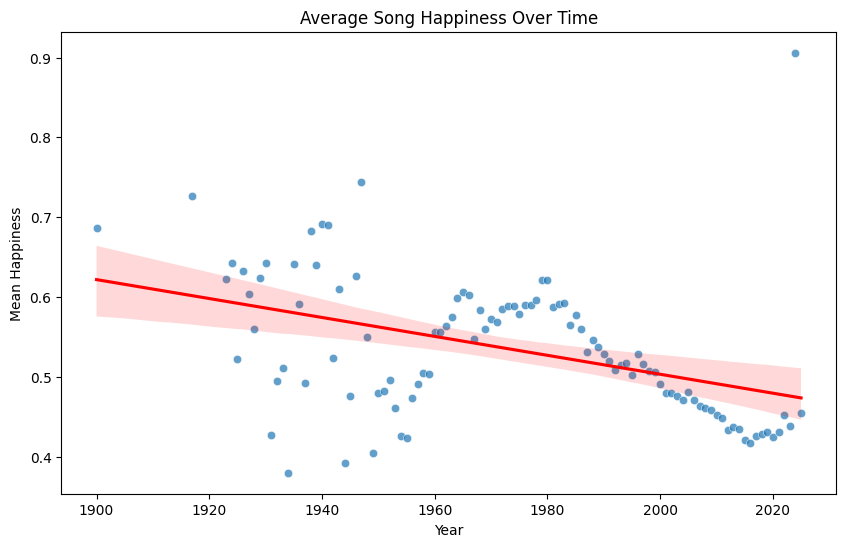

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=yearly, x="year", y="valence", alpha=0.7)
sns.regplot(data=yearly, x="year", y="valence", scatter=False, color="red")

plt.title("Average Song Happiness Over Time")
plt.xlabel("Year")
plt.ylabel("Mean Happiness")
plt.show()

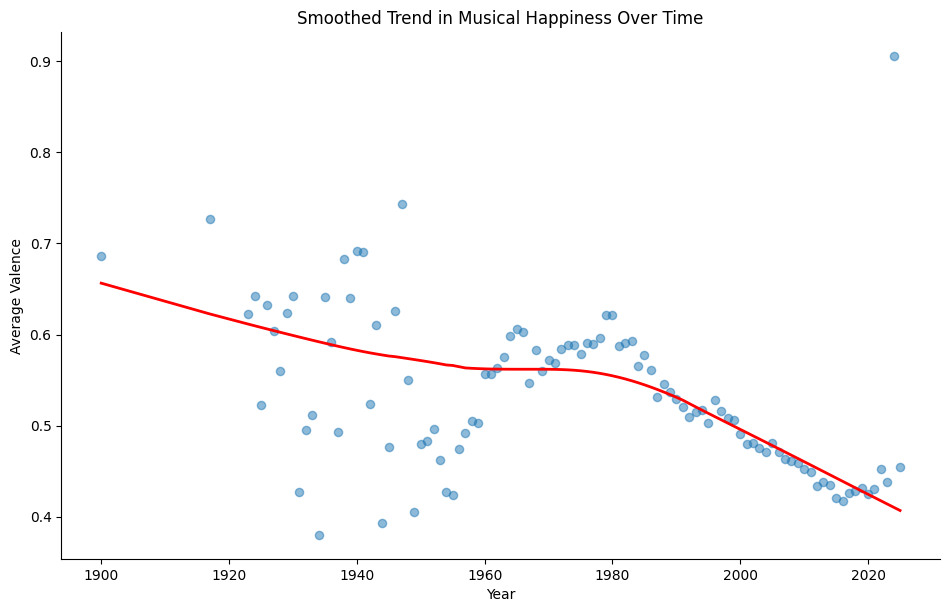

In [ ]:
sns.lmplot(
    data=yearly,
    x="year",
    y="valence",
    lowess=True,
    scatter_kws={"alpha": 0.5, "s": 35},
    line_kws={"color": "red", "lw": 2},
    height=6,
    aspect=1.6
)

plt.title("Smoothed Trend in Musical Happiness Over Time")
plt.xlabel("Year")
plt.ylabel("Average Valence")
plt.show()


In [ ]:
# Use yearly aggregated data
yearly = df.groupby("year")["valence"].mean().reset_index()

years = yearly["year"].values
y = yearly["valence"].values

results = []

# Avoid edges (need enough data on both sides)
candidate_years = range(int(years.min()) + 10, int(years.max()) - 10)

for c in candidate_years:
    hinge = np.maximum(0, years - c)

    X = np.column_stack([years, hinge])
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    results.append({
        "breakpoint": c,
        "aic": model.aic,
        "bic": model.bic,
        "rss": np.sum(model.resid**2)
    })

results_df = pd.DataFrame(results)

# Best breakpoint = lowest AIC
best = results_df.loc[results_df["aic"].idxmin()]
print(best)
#Fit final model with best breakpoint
best_c = int(best["breakpoint"])

yearly["hinge"] = np.maximum(0, yearly["year"] - best_c)

X = sm.add_constant(yearly[["year", "hinge"]])
model_bp = sm.OLS(yearly["valence"], X).fit()

print(model_bp.summary())




breakpoint    1981.000000
aic           -232.463949
bic           -224.502068
rss              0.634447
Name: 71, dtype: float64
                            OLS Regression Results                            
Dep. Variable:                valence   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     12.87
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.04e-05
Time:                        23:36:10   Log-Likelihood:                 119.23
No. Observations:                 105   AIC:                            -232.5
Df Residuals:                     102   BIC:                            -224.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--

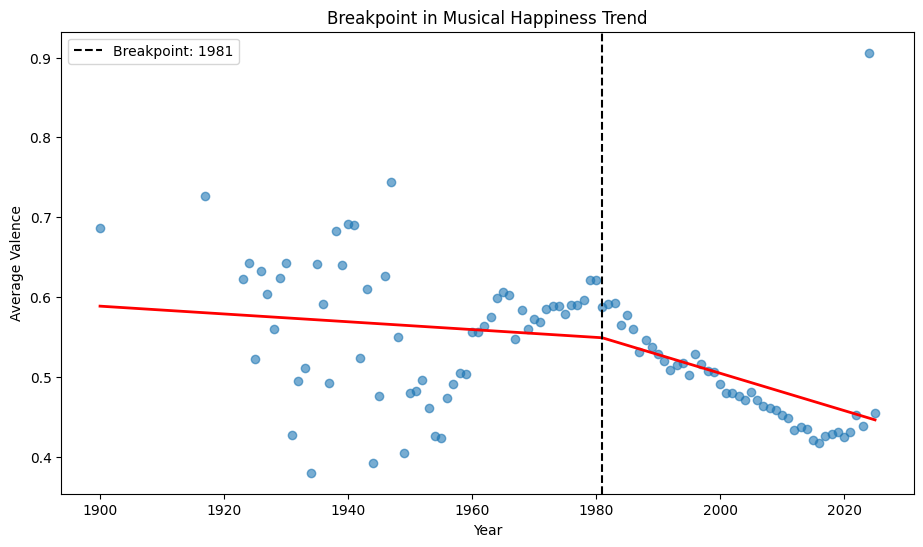

In [ ]:


# Plot with breakpoint
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

# scatter
plt.scatter(yearly["year"], yearly["valence"], alpha=0.6)

# predicted values
pred = model_bp.predict(X)
plt.plot(yearly["year"], pred, color="red", linewidth=2)

# vertical breakpoint line
plt.axvline(best_c, color="black", linestyle="--", label=f"Breakpoint: {best_c}")

plt.title("Breakpoint in Musical Happiness Trend")
plt.xlabel("Year")
plt.ylabel("Average Valence")
plt.legend()
plt.show()



In [ ]:
#To formally test if the breakpoint matters:

#Compare models:
#Model 1: simple linear trend
#Model 2: piecewise model
# simple model
X_simple = sm.add_constant(yearly["year"])
model_simple = sm.OLS(y, X_simple).fit()

# compare
print("Simple AIC:", model_simple.aic)
print("Breakpoint AIC:", model_bp.aic)



Simple AIC: -231.18367617801664
Breakpoint AIC: -232.46394905497937


In [ ]:
## moving on to sentiment analysis
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
### performing the sentiment analysis with VADER
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return "neutral"

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["lyrics"].apply(get_sentiment)

In [ ]:
df["compound"] = df["lyrics"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

df["sentiment"] = pd.cut(
    df["compound"],
    bins=[-1, -0.05, 0.05, 1],
    labels=["negative", "neutral", "positive"]
)

In [ ]:
print(df)

                            id                     name  \
0       0Prct5TDjAnEgIqbxcldY9                        !   
1       2ASl4wirkeYm3OWZxXKYuq                       !!   
2       5tA3ImW310llKo8EMBj2Ga      !!Noble Stabbings!!   
3       0fROT4kK5oTm8xO8PX6EJF           !I'll Be Back!   
4       1xBFhv5faebv3mmwxx7DnS                   !Lost!   
...                        ...                      ...   
550617  7ItLwpnDJNmnmjlx4hOC96  A Chance I'd Never Have   
550618  773j5fNWIjO0EWqAiX8Quo  It's Painless to Let Go   
550619  0fMJpTECbr7MwQYJjopAWf               Once Again   
550620  6yL5qOKgvBgn4H0XJEDyAV             Silver Bells   
550621  036JzAN5DCANSZyeW6MjqG        Winter Wonderland   

                             album_name                           artists  \
0                            UNDEN!ABLE                      ["HELLYEAH"]   
1                      Childhood Dreams                       ["Yxngxr1"]   
2                   Situationist Comedy                ["Dil

In [ ]:
# 1. Create era column
df['era'] = df['year'].apply(lambda x: 'pre_1975' if x < 1975 else 'post_1975')

# 2. Group and count genres
genre_counts = df.groupby(['era', 'genre']).size().reset_index(name='count')

print(genre_counts)

          era       genre   count
0   post_1975       Blues   13924
1   post_1975   Classical   11025
2   post_1975     Country   43568
3   post_1975  Electronic   69725
4   post_1975        Folk   48235
5   post_1975     Hip-Hop   41739
6   post_1975        Jazz   12554
7   post_1975         Pop   69425
8   post_1975         R&B   25838
9   post_1975        Rock  189882
10   pre_1975       Blues    2052
11   pre_1975   Classical    1148
12   pre_1975     Country    2508
13   pre_1975  Electronic      30
14   pre_1975        Folk    2608
15   pre_1975     Hip-Hop       6
16   pre_1975        Jazz    4456
17   pre_1975         Pop    3114
18   pre_1975         R&B    1499
19   pre_1975        Rock    7286


In [ ]:
#Checking distribution
df["sentiment"].value_counts(normalize=True)

,proportion
sentiment,
positive,0.589366
negative,0.394940
neutral,0.015694


In [ ]:
# Analyzing the datasets by post 1975 (the earliest preakpoint in valence, the breakpoint in sentiment is 1980

pre_1975 = df[df["year"] < 1975].copy()
post_1975 = df[df["year"] >= 1975].copy()


# Aggregate by Genre pre and post 1975

pre_summary = (
    pre_1975
    .groupby("genre")[["valence", "compound"]]
    .mean()
    .rename(columns={
        "valence": "valence_pre",
        "compound": "sentiment_pre"
    })
)

post_summary = (
    post_1975
    .groupby("genre")[["valence", "compound"]]
    .mean()
    .rename(columns={
        "valence": "valence_post",
        "compound": "sentiment_post"
    })
)


comparison = pre_summary.join(post_summary, how="inner")

comparison["valence_change"] = comparison["valence_post"] - comparison["valence_pre"]
comparison["sentiment_change"] = comparison["sentiment_post"] - comparison["sentiment_pre"]

comparison = comparison.sort_values("valence_change", ascending=False)


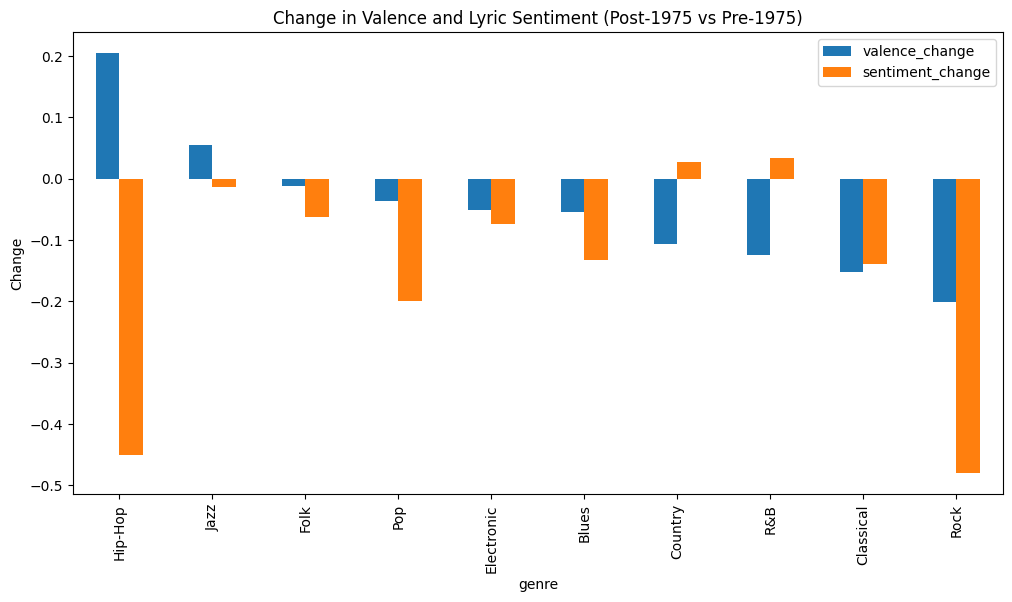

In [ ]:
#visuals for the sentiment and valence change
import matplotlib.pyplot as plt

comparison[["valence_change", "sentiment_change"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Change in Valence and Lyric Sentiment (Post-1975 vs Pre-1975)")
plt.ylabel("Change")
plt.show()

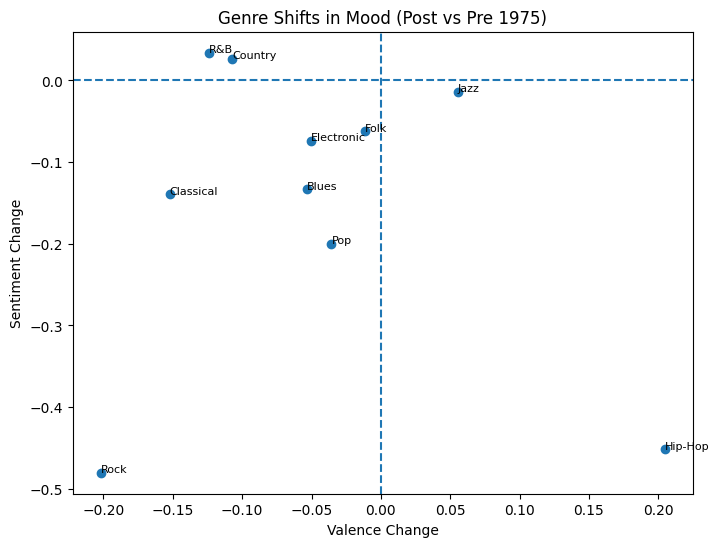

In [ ]:
#scatterplot of valence and
plt.figure(figsize=(8,6))
plt.scatter(
    comparison["valence_change"],
    comparison["sentiment_change"]
)

for genre in comparison.index:
    plt.text(
        comparison.loc[genre, "valence_change"],
        comparison.loc[genre, "sentiment_change"],
        genre,
        fontsize=8
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Valence Change")
plt.ylabel("Sentiment Change")
plt.title("Genre Shifts in Mood (Post vs Pre 1975)")
plt.show()

In [ ]:
# 1. Create era column
df['era'] = df['year'].apply(lambda x: 'pre_1975' if x < 1975 else 'post_1975')

# 2. Group and count genres
genre_counts = df.groupby(['era', 'genre']).size().reset_index(name='count')

print(genre_counts)

pivot = df.groupby(['genre', 'era']).size().unstack(fill_value=0)

print(pivot)

percent = pivot.div(pivot.sum(axis=1), axis=0) * 100
print(percent)

          era       genre   count
0   post_1975       Blues   13924
1   post_1975   Classical   11025
2   post_1975     Country   43568
3   post_1975  Electronic   69725
4   post_1975        Folk   48235
5   post_1975     Hip-Hop   41739
6   post_1975        Jazz   12554
7   post_1975         Pop   69425
8   post_1975         R&B   25838
9   post_1975        Rock  189882
10   pre_1975       Blues    2052
11   pre_1975   Classical    1148
12   pre_1975     Country    2508
13   pre_1975  Electronic      30
14   pre_1975        Folk    2608
15   pre_1975     Hip-Hop       6
16   pre_1975        Jazz    4456
17   pre_1975         Pop    3114
18   pre_1975         R&B    1499
19   pre_1975        Rock    7286
era         post_1975  pre_1975
genre                          
Blues           13924      2052
Classical       11025      1148
Country         43568      2508
Electronic      69725        30
Folk            48235      2608
Hip-Hop         41739         6
Jazz            12554      445

In [ ]:
import pandas as pd

# create era column
df['era'] = df['year'].apply(lambda x: 'pre_1975' if x < 1975 else 'post_1975')

# create pivot table
pivot = df.groupby(['genre', 'era']).size().unstack(fill_value=0)

# keep top genres for cleaner plots
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values(by='total', ascending=False).head(10)

# drop total column for plotting
pivot_plot = pivot.drop(columns='total')

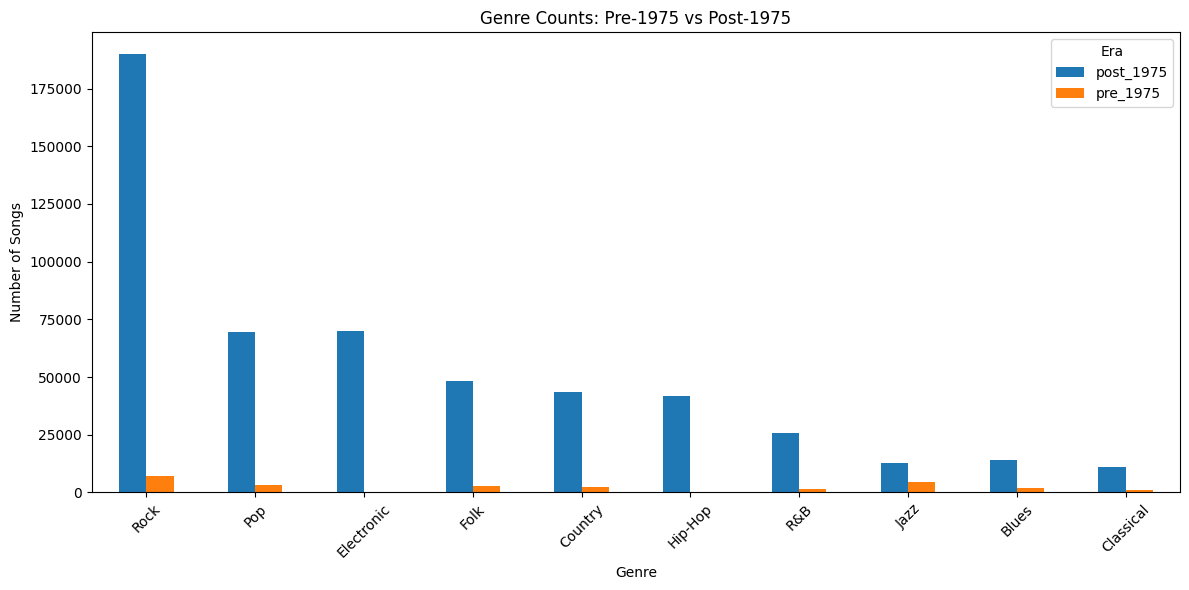

In [ ]:
import matplotlib.pyplot as plt

pivot_plot.plot(kind='bar', figsize=(12,6))

plt.title('Genre Counts: Pre-1975 vs Post-1975')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)
plt.legend(title='Era')
plt.tight_layout()

plt.show()

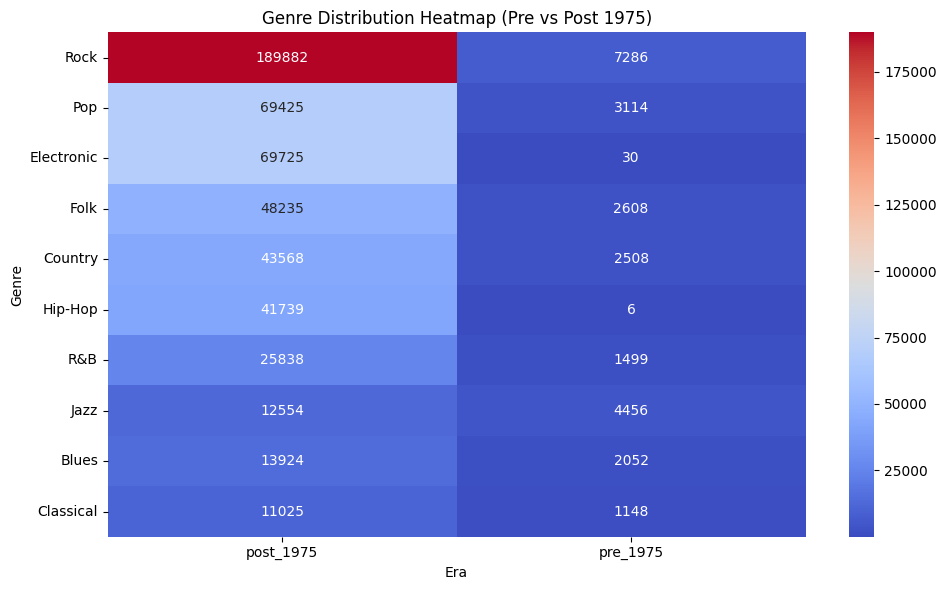

In [ ]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(pivot_plot, annot=True, fmt='d', cmap='coolwarm')

plt.title('Genre Distribution Heatmap (Pre vs Post 1975)')
plt.xlabel('Era')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

<Axes: xlabel='era', ylabel='genre'>

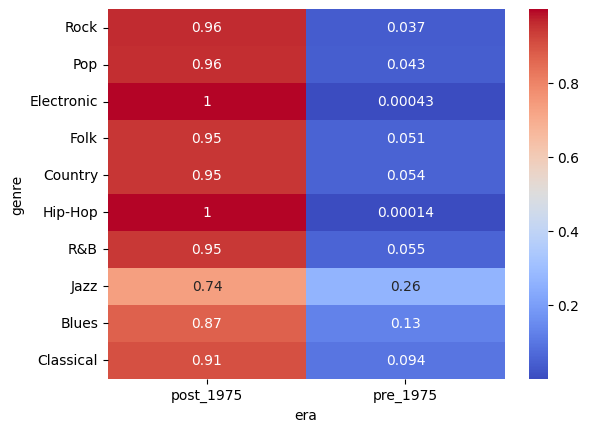

In [ ]:
#Normalized Heatmap

pivot_norm = pivot_plot.div(pivot_plot.sum(axis=1), axis=0)

sns.heatmap(pivot_norm, annot=True, cmap='coolwarm')

In [ ]:
#Wordcloud
pip install wordcloud matplotlib

In [ ]:
# Wordcloud Keeps crashing
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# create era column
df['era'] = df['year'].apply(lambda x: 'pre_1975' if x < 1975 else 'post_1975')

# drop missing lyrics
df_clean = df.dropna(subset=['lyrics'])

In [ ]:
#Wordcloud keeps crashing
pre_lyrics = " ".join(df_clean[df_clean['era'] == 'pre_1975']['lyrics'])
post_lyrics = " ".join(df_clean[df_clean['era'] == 'post_1975']['lyrics'])

In [ ]:
#wordcloud keeps crashing
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pre-1975
wc_pre = WordCloud(width=800, height=400, background_color='white').generate(pre_lyrics)
axes[0].imshow(wc_pre, interpolation='bilinear')
axes[0].set_title('Pre-1975 Lyrics')
axes[0].axis('off')

# Post-1975
wc_post = WordCloud(width=800, height=400, background_color='white').generate(post_lyrics)
axes[1].imshow(wc_post, interpolation='bilinear')
axes[1].set_title('Post-1975 Lyrics')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#wordcloud keeps crashing
from wordcloud import STOPWORDS

custom_stopwords = set(STOPWORDS).union({
    'yeah', 'oh', 'la', 'na', 'baby', 'got', 'one', 'like'
})

wc_pre = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords
).generate(pre_lyrics)

wc_post = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords
).generate(post_lyrics)

In [ ]:
from collections import Counter

pre_words = Counter(pre_lyrics.split())
post_words = Counter(post_lyrics.split())

# words more common post-1975
diff = {word: post_words[word] - pre_words[word]
        for word in post_words if post_words[word] > pre_words[word]}



In [ ]:
#Performing the linear regression on the sentiment analysis ratings
import pandas as pd
import statsmodels.api as sm

# Aggregate sentiment by year
yearly_sentiment = (
    df.groupby("year")["compound"]
      .mean()
      .reset_index()
      .dropna()
)

#sentiment=β0​+β1​⋅year

X = yearly_sentiment["year"]
y = yearly_sentiment["compound"]

# add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

#one sided Hypothesis test
beta = model.params["year"]
p_two_sided = model.pvalues["year"]

# convert to one-sided p-value
if beta < 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - (p_two_sided / 2)

print("Slope (beta):", beta)
print("One-sided p-value:", p_one_sided)

                            OLS Regression Results                            
Dep. Variable:               compound   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     75.78
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           5.53e-14
Time:                        00:33:46   Log-Likelihood:                 19.979
No. Observations:                 105   AIC:                            -35.96
Df Residuals:                     103   BIC:                            -30.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.3420      1.263      8.983      0.0

In [ ]:
# finding the breakpoint of sentiment
import numpy as np
import pandas as pd
import statsmodels.api as sm

# yearly aggregation
yearly_sentiment = df.groupby("year")["compound"].mean().reset_index()

years = yearly_sentiment["year"].values
y = yearly_sentiment["compound"].values

results = []

candidate_years = range(int(years.min()) + 10, int(years.max()) - 10)

for c in candidate_years:
    hinge = np.maximum(0, years - c)

    X = np.column_stack([years, hinge])
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    results.append({
        "breakpoint": c,
        "aic": model.aic,
        "rss": np.sum(model.resid**2)
    })

results_df = pd.DataFrame(results)

best = results_df.loc[results_df["aic"].idxmin()]
best_c_sent = int(best["breakpoint"])

print("Best sentiment breakpoint:", best_c_sent)

Best sentiment breakpoint: 1951


In [ ]:
# Fit final sentiment breakpoint model
yearly_sentiment["hinge"] = np.maximum(0, yearly_sentiment["year"] - best_c_sent)

X = sm.add_constant(yearly_sentiment[["year", "hinge"]])
model_sent_bp = sm.OLS(yearly_sentiment["compound"], X).fit()

print(model_sent_bp.summary())

                            OLS Regression Results                            
Dep. Variable:               compound   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     70.76
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           5.31e-20
Time:                        00:33:56   Log-Likelihood:                 36.717
No. Observations:                 105   AIC:                            -67.43
Df Residuals:                     102   BIC:                            -59.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.4292      4.146     -3.239      0.0

In [ ]:
# Compute both slopes
# sentiment model
X_sent = sm.add_constant(yearly_sentiment["year"])
model_sent = sm.OLS(yearly_sentiment["compound"], X_sent).fit()

# valence model
yearly_valence = df.groupby("year")["valence"].mean().reset_index()

X_val = sm.add_constant(yearly_valence["year"])
model_val = sm.OLS(yearly_valence["valence"], X_val).fit()

beta_sent = model_sent.params["year"]
beta_val = model_val.params["year"]

print("Sentiment slope:", beta_sent)
print("Valence slope:", beta_val)

Sentiment slope: -0.0055707650013016065
Valence slope: -0.0011853471615467708


In [ ]:
# test if slopes differ statistically
sent_df = yearly_sentiment[["year", "compound"]].copy()
sent_df["type"] = "sentiment"
sent_df = sent_df.rename(columns={"compound": "value"})

val_df = yearly_valence[["year", "valence"]].copy()
val_df["type"] = "valence"
val_df = val_df.rename(columns={"valence": "value"})

combined = pd.concat([sent_df, val_df], ignore_index=True)

# binary indicator
combined["is_sentiment"] = (combined["type"] == "sentiment").astype(int)

In [ ]:
# Run Interaction Regression, interaction = difference in slopes,
#Slopes from this model:
#Valence slope = β₁
#Sentiment slope = β₁ + β₃

combined["interaction"] = combined["year"] * combined["is_sentiment"]

X = sm.add_constant(combined[["year", "is_sentiment", "interaction"]])
y = combined["value"]

model_compare = sm.OLS(y, X).fit()

print(model_compare.summary())

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     70.64
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.86e-31
Time:                        00:34:40   Log-Likelihood:                 97.537
No. Observations:                 210   AIC:                            -187.1
Df Residuals:                     206   BIC:                            -173.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.8740      0.960      2.994   

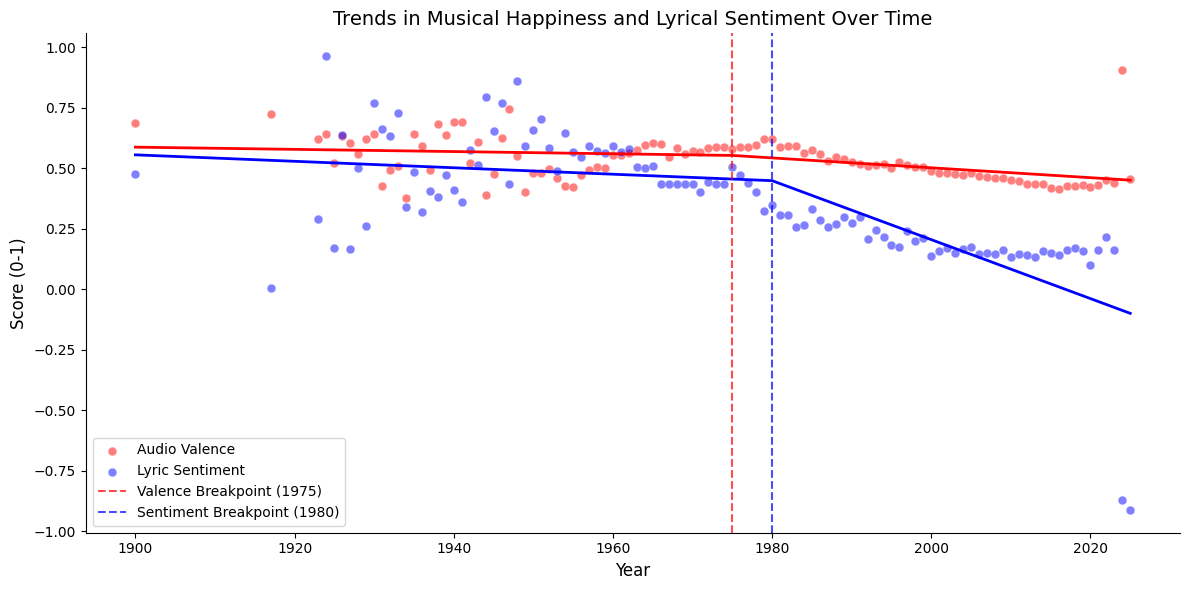

In [ ]:
## Killer comparison figure

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# --- Aggregate yearly averages ---
yearly_valence = df.groupby("year")["valence"].mean().reset_index()
yearly_sentiment = df.groupby("year")["compound"].mean().reset_index()

# --- Compute breakpoints (from previous step) ---
# Example: you already computed best_c_val and best_c_sent
best_c_val = 1975   # replace with your computed breakpoint for valence
best_c_sent = 1980  # replace with your computed breakpoint for sentiment

# --- Add hinge terms for piecewise regression ---
yearly_valence["hinge"] = np.maximum(0, yearly_valence["year"] - best_c_val)
yearly_sentiment["hinge"] = np.maximum(0, yearly_sentiment["year"] - best_c_sent)

# --- Fit piecewise linear models ---
X_val = sm.add_constant(yearly_valence[["year", "hinge"]])
model_val = sm.OLS(yearly_valence["valence"], X_val).fit()
yearly_valence["pred"] = model_val.predict(X_val)

X_sent = sm.add_constant(yearly_sentiment[["year", "hinge"]])
model_sent = sm.OLS(yearly_sentiment["compound"], X_sent).fit()
yearly_sentiment["pred"] = model_sent.predict(X_sent)

# --- Plot ---
plt.figure(figsize=(12,6))

# scatter plots
sns.scatterplot(x="year", y="valence", data=yearly_valence, color="red", alpha=0.5, s=40, label="Audio Valence")
sns.scatterplot(x="year", y="compound", data=yearly_sentiment, color="blue", alpha=0.5, s=40, label="Lyric Sentiment")

# regression lines
plt.plot(yearly_valence["year"], yearly_valence["pred"], color="red", lw=2)
plt.plot(yearly_sentiment["year"], yearly_sentiment["pred"], color="blue", lw=2)

# breakpoints
plt.axvline(best_c_val, color="red", linestyle="--", alpha=0.7, label=f"Valence Breakpoint ({best_c_val})")
plt.axvline(best_c_sent, color="blue", linestyle="--", alpha=0.7, label=f"Sentiment Breakpoint ({best_c_sent})")

# labels
plt.title("Trends in Musical Happiness and Lyrical Sentiment Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Score (0-1)", fontsize=12)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

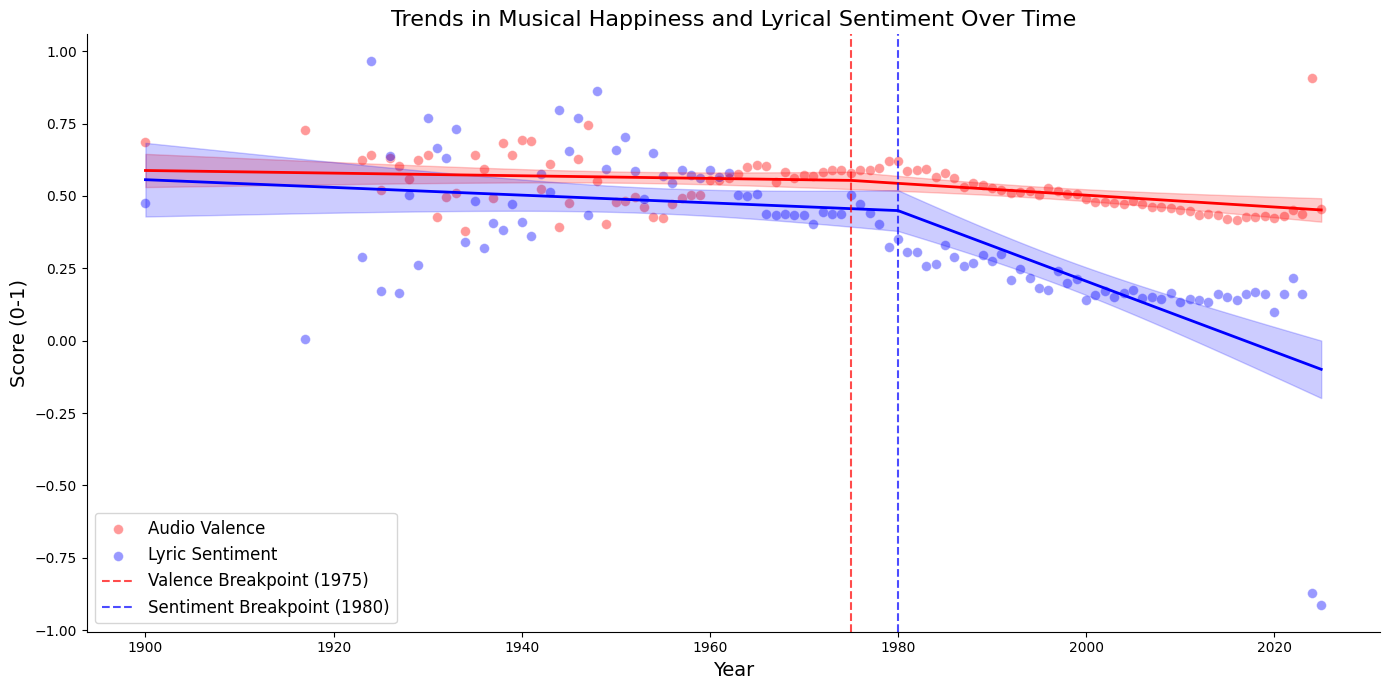

In [ ]:
#more polished version
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# --- Aggregate yearly averages ---
yearly_valence = df.groupby("year")["valence"].mean().reset_index()
yearly_sentiment = df.groupby("year")["compound"].mean().reset_index()

# --- Breakpoints (replace with your computed values) ---
best_c_val = 1975
best_c_sent = 1980

# --- Add hinge terms ---
yearly_valence["hinge"] = np.maximum(0, yearly_valence["year"] - best_c_val)
yearly_sentiment["hinge"] = np.maximum(0, yearly_sentiment["year"] - best_c_sent)

# --- Fit piecewise linear regression ---
X_val = sm.add_constant(yearly_valence[["year", "hinge"]])
model_val = sm.OLS(yearly_valence["valence"], X_val).fit()
yearly_valence["pred"] = model_val.predict(X_val)
pred_val_ci = model_val.get_prediction(X_val).summary_frame(alpha=0.05)

X_sent = sm.add_constant(yearly_sentiment[["year", "hinge"]])
model_sent = sm.OLS(yearly_sentiment["compound"], X_sent).fit()
yearly_sentiment["pred"] = model_sent.predict(X_sent)
pred_sent_ci = model_sent.get_prediction(X_sent).summary_frame(alpha=0.05)

# --- Create figure ---
plt.figure(figsize=(14,7))

# scatter plots
sns.scatterplot(x="year", y="valence", data=yearly_valence, color="red", alpha=0.4, s=50, label="Audio Valence")
sns.scatterplot(x="year", y="compound", data=yearly_sentiment, color="blue", alpha=0.4, s=50, label="Lyric Sentiment")

# regression lines
plt.plot(yearly_valence["year"], yearly_valence["pred"], color="red", lw=2)
plt.plot(yearly_sentiment["year"], yearly_sentiment["pred"], color="blue", lw=2)

# confidence intervals
plt.fill_between(yearly_valence["year"], pred_val_ci["mean_ci_lower"], pred_val_ci["mean_ci_upper"], color="red", alpha=0.2)
plt.fill_between(yearly_sentiment["year"], pred_sent_ci["mean_ci_lower"], pred_sent_ci["mean_ci_upper"], color="blue", alpha=0.2)

# breakpoints
plt.axvline(best_c_val, color="red", linestyle="--", alpha=0.7, label=f"Valence Breakpoint ({best_c_val})")
plt.axvline(best_c_sent, color="blue", linestyle="--", alpha=0.7, label=f"Sentiment Breakpoint ({best_c_sent})")

# labels and title
plt.title("Trends in Musical Happiness and Lyrical Sentiment Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Score (0-1)", fontsize=14)
plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
###You are now answering:

##Are songs getting sadder?
##When did that change happen?
##Is it happening in both sound AND lyrics?
##Which is changing faster?

In [ ]:
import pandas as pd
import numpy as np

# NLP preprocessing libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Download NLTK resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


# 2. Text Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_lyrics(text):
    # Tokenize
    tokens = word_tokenize(text.lower())
    # Remove stopwords and non-alphabetic tokens
    filtered = [word for word in tokens if word.isalpha() and word not in stop_words]
    # Lemmatize
    lemmas = [lemmatizer.lemmatize(word) for word in filtered]
    return " ".join(lemmas)

df['lyrics_clean'] = df['lyrics'].apply(preprocess_lyrics)

# -------------------------
# 3. Feature extraction: TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['lyrics_clean'])

# -------------------------
# 4. Labels encoding
# Map sentiments to numeric
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['sentiment'].map(label_map)

# -------------------------
# 5. Train/test split
# Increased test_size to ensure at least 3 samples in the test set for 3 classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# -------------------------
# 6. Train classifier: Logistic Regression (easy, effective)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# -------------------------
# 7. Evaluation
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# -------------------------
# 8. Prediction function for new lyrics
def predict_lyric_sentiment(lyrics_text):
    processed = preprocess_lyrics(lyrics_text)
    features = vectorizer.transform([processed])
    pred_label_num = clf.predict(features)[0]
    # Map back to string label
    inv_label_map = {v: k for k, v in label_map.items()}
    sentiment = inv_label_map[pred_label_num]

    # Recommendation example (customize to user preference)
    recommendation = "Recommended" if sentiment == "positive" else "Not recommended"
    return sentiment, recommendation



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -------------------------
# 1. Minimal text cleaning (FAST)
df['lyrics_clean'] = df['lyrics'].astype(str)

# -------------------------
# 2. TF-IDF (does preprocessing internally, very fast)
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',   # built-in stopword removal
    lowercase=True,
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'  # keep real words only
)

X = vectorizer.fit_transform(df['lyrics_clean'])

# -------------------------
# 3. Labels encoding
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['sentiment'].map(label_map)

# Handle NaN values in y before train/test split
if y.isnull().any():
    print(f"NaN values found in y. Total NaNs: {y.isnull().sum()}")
    valid_indices = y.dropna().index
    X_filtered = X[valid_indices] # Filter X based on valid indices
    y_filtered = y.loc[valid_indices] # Filter y based on valid indices
    print(f"Number of samples after dropping NaNs: {len(y_filtered)}")
else:
    X_filtered = X
    y_filtered = y

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# -------------------------
# 5. Train classifier (optimized)
clf = LogisticRegression(
    max_iter=300,
    n_jobs=-1   # uses all CPU cores
)

clf.fit(X_train, y_train)

# -------------------------
# 6. Evaluation
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# -------------------------
# 7. Prediction function
def predict_lyric_sentiment(lyrics_text):
    features = vectorizer.transform([lyrics_text])
    pred_label_num = clf.predict(features)[0]

    inv_label_map = {v: k for k, v in label_map.items()}
    sentiment = inv_label_map[pred_label_num]

    recommendation = "Recommended" if sentiment == "positive" else "Not recommended"
    return sentiment, recommendation

In [ ]:
# Example usage:
new_lyrics = "Every breath you take And every move you make Every bond you break Every step you takeI'll be watching you Everysingle day And every word you say Every game you play Every night you stay I'll be watching you Oh, can't you see You belong to me? How my poor heart aches With every step you take? Every move you make And every vow you break Every smile you fake Every claim you stake I'll be watching you Since you've gone, I've been lost without a trace I dream at night, I can only see your face I look around, but it's you I can't replace I feel so cold, and I long for your embrace I keep crying, baby, baby please Oh, can't you see You belong to me? How my poor heart aches With every step you take? Every move you make And every vow you break Every smile you fake Every claim you stake I'll be watching you Every move you make Every step you take I'll be watching you I'll be watching you(Every breath you take)(Every move you make)(Every bond you break)(Every step you take) I'll be watching you I'll be watching you I'll be watching you whoo, hoo (Every game you play)(Every night you stay) I'll be watching you I'll be watching you I'll be watching you I'll be watching you(Every single day)(Every word you say)(Every game you play)(Every night you stay) I'll be watching you"
sentiment, recommendation = predict_lyric_sentiment(new_lyrics)
print(f"Predicted sentiment: {sentiment}")
print(f"Recommendation: {recommendation}")